# House Prices Prediction Project

## 1. Imports

In [21]:
# =========================
# 1. Imports
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost is not installed. Install it with: !pip install xgboost")

## 2. Load Data

In [22]:
# =========================
# 2. Load Data
# =========================

DATA_PATH = "/content/train.csv"    # Update this path if running outside Google Colab

hp = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", hp.shape)

hp.head()

Dataset loaded successfully.
Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Initial Data Review

In [23]:
# =========================
# 3. Initial Data Review
# =========================

print("First five rows:")
display(hp.head())

print("\nDataset information:")
hp.info()

print("\nSummary statistics for numerical columns:")
display(hp.describe())

print("\nNumber of duplicated rows:", hp.duplicated().sum())

First five rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null  

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000



Number of duplicated rows: 0


## 4. Missing Value Analysis

In [24]:
# =========================
# 4. Missing Value Analysis
# =========================

missing_count = hp.isnull().sum().sort_values(ascending=False)
missing_count = missing_count[missing_count > 0]

missing_percent = (hp.isnull().sum() / len(hp) * 100).sort_values(ascending=False)
missing_percent = missing_percent[missing_percent > 0]

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
})

display(missing_summary)

print("Number of columns with missing values:", len(missing_summary))

,missing_count,missing_percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageQual,81,5.547945
GarageFinish,81,5.547945
GarageType,81,5.547945


Number of columns with missing values: 19


## 5. Data Cleaning

In [25]:
# =========================
# 5. Data Cleaning
# =========================

# Create a copy to keep the original dataset unchanged
hp_clean = hp.copy()

# Drop columns with too many missing values
drop_cols = ["PoolQC", "MiscFeature", "Alley", "Fence"]
hp_clean = hp_clean.drop(columns=drop_cols)

# Fill categorical missing values with "None"
none_fill_cols = [
    "MasVnrType",
    "FireplaceQu",
    "GarageQual", "GarageFinish", "GarageType", "GarageCond",
    "BsmtFinType2", "BsmtExposure", "BsmtCond", "BsmtQual", "BsmtFinType1"
]

for col in none_fill_cols:
    hp_clean[col] = hp_clean[col].fillna("None")

# Fill selected numerical missing values with 0
zero_fill_cols = ["GarageYrBlt", "MasVnrArea"]

for col in zero_fill_cols:
    hp_clean[col] = hp_clean[col].fillna(0)

# Fill LotFrontage with median
hp_clean["LotFrontage"] = hp_clean["LotFrontage"].fillna(hp_clean["LotFrontage"].median())

# Fill Electrical with mode
hp_clean["Electrical"] = hp_clean["Electrical"].fillna(hp_clean["Electrical"].mode()[0])

# Check remaining missing values
remaining_missing = hp_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

print("Remaining missing values after cleaning:")
display(remaining_missing)

print("Cleaned dataset shape:", hp_clean.shape)

Remaining missing values after cleaning:


,0


Cleaned dataset shape: (1460, 77)


## 6. Exploratory Data Analysis

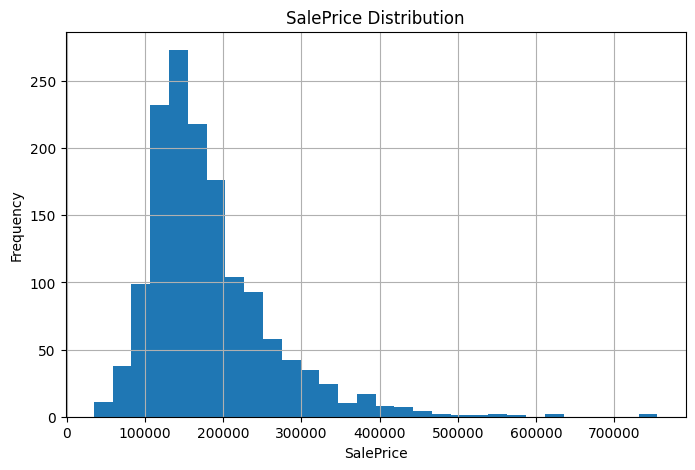

SalePrice summary statistics:


,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


Top numerical correlations with SalePrice:


,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


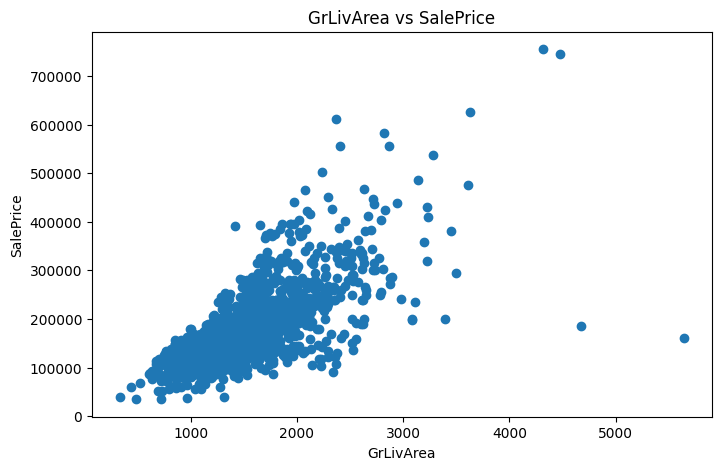

Average SalePrice by OverallQual:


,SalePrice
OverallQual,
1,50150.000000
2,51770.333333
3,87473.750000
4,108420.655172
5,133523.347607
6,161603.034759
7,207716.423197
8,274735.535714
9,367513.023256


In [26]:
# =========================
# 6. Exploratory Data Analysis
# =========================

# Target variable distribution
plt.figure(figsize=(8, 5))
hp_clean["SalePrice"].hist(bins=30)
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.title("SalePrice Distribution")
plt.show()

# Basic target statistics
print("SalePrice summary statistics:")
display(hp_clean["SalePrice"].describe())

# Correlation with target for numerical variables
corr_with_target = hp_clean.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

print("Top numerical correlations with SalePrice:")
display(corr_with_target.head(15))

# GrLivArea vs SalePrice
plt.figure(figsize=(8, 5))
plt.scatter(hp_clean["GrLivArea"], hp_clean["SalePrice"])
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("GrLivArea vs SalePrice")
plt.show()

# OverallQual vs average SalePrice
overallqual_price = hp_clean.groupby("OverallQual")["SalePrice"].mean()

print("Average SalePrice by OverallQual:")
display(overallqual_price)

## 7. Outlier Handling

Potential outliers based on high GrLivArea and relatively low SalePrice:


,GrLivArea,SalePrice,OverallQual,Neighborhood
523,4676,184750,10,Edwards
1298,5642,160000,10,Edwards


Shape before outlier removal: (1460, 77)
Shape after outlier removal: (1458, 77)


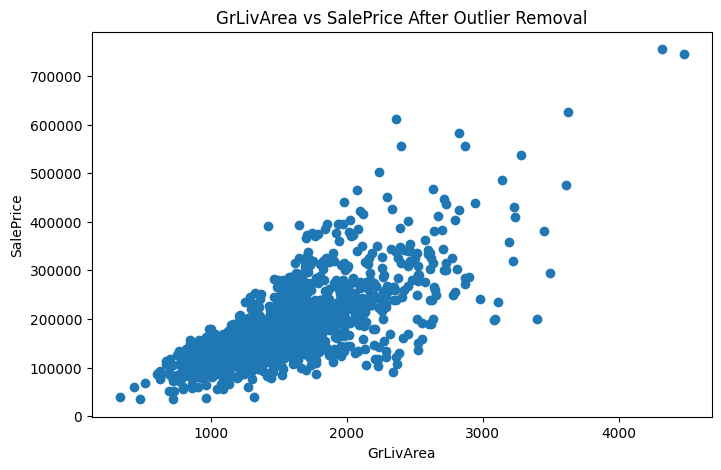

In [27]:
# =========================
# 7. Outlier Handling
# =========================

# Inspect potential outliers in GrLivArea vs SalePrice
potential_outliers = hp_clean[
    (hp_clean["GrLivArea"] > 4000) &
    (hp_clean["SalePrice"] < 300000)
]

print("Potential outliers based on high GrLivArea and relatively low SalePrice:")
display(potential_outliers[["GrLivArea", "SalePrice", "OverallQual", "Neighborhood"]])

# Remove the two identified outliers
hp_clean2 = hp_clean.drop(index=[523, 1298])

print("Shape before outlier removal:", hp_clean.shape)
print("Shape after outlier removal:", hp_clean2.shape)

# Visual check after outlier removal
plt.figure(figsize=(8, 5))
plt.scatter(hp_clean2["GrLivArea"], hp_clean2["SalePrice"])
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("GrLivArea vs SalePrice After Outlier Removal")
plt.show()

## 8. Feature Engineering

In [28]:
# =========================
# 8. Feature Engineering
# =========================

# Total house size
hp_clean2["TotalSF"] = (
    hp_clean2["TotalBsmtSF"]
    + hp_clean2["1stFlrSF"]
    + hp_clean2["2ndFlrSF"]
)

# Age of the house at the time of sale
hp_clean2["HouseAge"] = hp_clean2["YrSold"] - hp_clean2["YearBuilt"]

# Years since last remodel at the time of sale
hp_clean2["RemodAge"] = hp_clean2["YrSold"] - hp_clean2["YearRemodAdd"]

# Total bathroom count with half-baths weighted as 0.5
hp_clean2["TotalBath"] = (
    hp_clean2["FullBath"]
    + 0.5 * hp_clean2["HalfBath"]
    + hp_clean2["BsmtFullBath"]
    + 0.5 * hp_clean2["BsmtHalfBath"]
)

engineered_features = ["TotalSF", "HouseAge", "RemodAge", "TotalBath"]

print("Engineered features created:")
display(hp_clean2[engineered_features].head())

Engineered features created:


,TotalSF,HouseAge,RemodAge,TotalBath
0,2566,5,5,3.5
1,2524,31,31,2.5
2,2706,7,6,3.5
3,2473,91,36,2.0
4,3343,8,8,3.5


## 9. Final Feature Set and Train-Test Split

In [29]:
# =========================
# 9. Final Feature Set and Train-Test Split
# =========================

features_final = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "Neighborhood",
    "TotalBsmtSF",
    "HouseAge",
    "RemodAge",
    "TotalBath"
]

X_final = hp_clean2[features_final].copy()
y = hp_clean2["SalePrice"]

# One-hot encode Neighborhood
X_final = pd.get_dummies(
    X_final,
    columns=["Neighborhood"],
    drop_first=True
)

# Log-transform target
y_log = np.log1p(y)

# Train-test split
X_train, X_test, y_train, y_test, y_log_train, y_log_test = train_test_split(
    X_final,
    y,
    y_log,
    test_size=0.2,
    random_state=42
)

print("Final feature matrix shape:", X_final.shape)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Number of features after encoding:", X_train.shape[1])

Final feature matrix shape: (1458, 32)
Train shape: (1166, 32)
Test shape: (292, 32)
Number of features after encoding: 32


## 10. Evaluation Helper Function

In [30]:
# =========================
# 10. Evaluation Helper Function
# =========================

def evaluate_predictions(y_true, y_pred, model_name):
    """
    Evaluate model predictions on the original SalePrice scale.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "R² Original Scale": r2,
        "MAE": mae,
        "RMSE": rmse
    }

## 11. Baseline Linear Regression

In [31]:
# =========================
# 11. Baseline Linear Regression
# =========================

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

linear_results = evaluate_predictions(
    y_true=y_test,
    y_pred=y_pred_linear,
    model_name="Baseline Linear Regression"
)

linear_results

{'Model': 'Baseline Linear Regression',
 'R² Original Scale': 0.8409543154723256,
 'MAE': 21940.70951678561,
 'RMSE': np.float64(29639.922382875644)}

## 12. Log-Target Linear Regression

In [32]:
# =========================
# 12. Log-Target Linear Regression
# =========================

log_linear_model = LinearRegression()

log_linear_model.fit(X_train, y_log_train)

y_log_pred_linear = log_linear_model.predict(X_test)

# Convert predictions back to original SalePrice scale
y_pred_log_linear = np.expm1(y_log_pred_linear)

log_linear_results = evaluate_predictions(
    y_true=y_test,
    y_pred=y_pred_log_linear,
    model_name="Log-Target Linear Regression"
)

log_linear_results

{'Model': 'Log-Target Linear Regression',
 'R² Original Scale': 0.8834461264273084,
 'MAE': 18259.063136718887,
 'RMSE': np.float64(25373.44714819766)}

## 13. Decision Tree Models

In [33]:
# =========================
# 13. Decision Tree Models
# =========================

# Untuned Decision Tree
decision_tree = DecisionTreeRegressor(random_state=42)

decision_tree.fit(X_train, y_log_train)

y_log_pred_dt = decision_tree.predict(X_test)
y_pred_dt = np.expm1(y_log_pred_dt)

dt_results = evaluate_predictions(
    y_true=y_test,
    y_pred=y_pred_dt,
    model_name="Untuned Decision Tree"
)

# Tuned Decision Tree
tuned_decision_tree = DecisionTreeRegressor(
    max_depth=6,
    min_samples_leaf=20,
    random_state=42
)

tuned_decision_tree.fit(X_train, y_log_train)

y_log_pred_tuned_dt = tuned_decision_tree.predict(X_test)
y_pred_tuned_dt = np.expm1(y_log_pred_tuned_dt)

tuned_dt_results = evaluate_predictions(
    y_true=y_test,
    y_pred=y_pred_tuned_dt,
    model_name="Tuned Decision Tree"
)

dt_results, tuned_dt_results

({'Model': 'Untuned Decision Tree',
  'R² Original Scale': 0.7408764575137325,
  'MAE': 26132.344083047345,
  'RMSE': np.float64(37832.89310692551)},
 {'Model': 'Tuned Decision Tree',
  'R² Original Scale': 0.8019871881714881,
  'MAE': 23321.820791707163,
  'RMSE': np.float64(33072.17540491184)})

In [34]:
# Decision Tree overfitting check

dt_train_r2 = r2_score(y_log_train, decision_tree.predict(X_train))
dt_test_r2 = r2_score(y_log_test, decision_tree.predict(X_test))

tuned_dt_train_r2 = r2_score(y_log_train, tuned_decision_tree.predict(X_train))
tuned_dt_test_r2 = r2_score(y_log_test, tuned_decision_tree.predict(X_test))

print("Untuned Decision Tree Train R² log:", dt_train_r2)
print("Untuned Decision Tree Test R² log:", dt_test_r2)
print("Untuned Decision Tree Gap:", dt_train_r2 - dt_test_r2)

print("\nTuned Decision Tree Train R² log:", tuned_dt_train_r2)
print("Tuned Decision Tree Test R² log:", tuned_dt_test_r2)
print("Tuned Decision Tree Gap:", tuned_dt_train_r2 - tuned_dt_test_r2)

Untuned Decision Tree Train R² log: 0.999897313012481
Untuned Decision Tree Test R² log: 0.7315556291961083
Untuned Decision Tree Gap: 0.2683416838163727

Tuned Decision Tree Train R² log: 0.8313599444233191
Tuned Decision Tree Test R² log: 0.7858238202063585
Tuned Decision Tree Gap: 0.045536124216960516


## 14. Random Forest

In [35]:
# =========================
# 14. Random Forest
# =========================

random_forest = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_log_train)

y_log_pred_rf = random_forest.predict(X_test)
y_pred_rf = np.expm1(y_log_pred_rf)

rf_results = evaluate_predictions(
    y_true=y_test,
    y_pred=y_pred_rf,
    model_name="Random Forest"
)

rf_train_r2 = r2_score(y_log_train, random_forest.predict(X_train))
rf_test_r2 = r2_score(y_log_test, y_log_pred_rf)

print("Random Forest Train R² log:", rf_train_r2)
print("Random Forest Test R² log:", rf_test_r2)
print("Random Forest Gap:", rf_train_r2 - rf_test_r2)

rf_results

Random Forest Train R² log: 0.9663084131314412
Random Forest Test R² log: 0.8473263279939202
Random Forest Gap: 0.11898208513752107


{'Model': 'Random Forest',
 'R² Original Scale': 0.8732259619402429,
 'MAE': 18293.50406717908,
 'RMSE': np.float64(26462.52486757556)}

## 15. Gradient Boosting

In [36]:
# =========================
# 15. Gradient Boosting
# =========================

gradient_boosting = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gradient_boosting.fit(X_train, y_log_train)

y_log_pred_gb = gradient_boosting.predict(X_test)
y_pred_gb = np.expm1(y_log_pred_gb)

gb_results = evaluate_predictions(
    y_true=y_test,
    y_pred=y_pred_gb,
    model_name="Tuned Gradient Boosting"
)

gb_train_r2 = r2_score(y_log_train, gradient_boosting.predict(X_train))
gb_test_r2 = r2_score(y_log_test, y_log_pred_gb)

print("Gradient Boosting Train R² log:", gb_train_r2)
print("Gradient Boosting Test R² log:", gb_test_r2)
print("Gradient Boosting Gap:", gb_train_r2 - gb_test_r2)

gb_results

Gradient Boosting Train R² log: 0.9652232413710629
Gradient Boosting Test R² log: 0.8695756323677652
Gradient Boosting Gap: 0.0956476090032976


{'Model': 'Tuned Gradient Boosting',
 'R² Original Scale': 0.9008519904839484,
 'MAE': 16804.26904757717,
 'RMSE': np.float64(23402.277083564244)}

## 16. Model Comparison

In [37]:
# =========================
# 16. Model Comparison
# =========================

model_results = pd.DataFrame([
    linear_results,
    log_linear_results,
    dt_results,
    tuned_dt_results,
    rf_results,
    gb_results
])

model_results = model_results.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

display(model_results)

,Model,R² Original Scale,MAE,RMSE
0,Tuned Gradient Boosting,0.900852,16804.269048,23402.277084
1,Log-Target Linear Regression,0.883446,18259.063137,25373.447148
2,Random Forest,0.873226,18293.504067,26462.524868
3,Baseline Linear Regression,0.840954,21940.709517,29639.922383
4,Tuned Decision Tree,0.801987,23321.820792,33072.175405
5,Untuned Decision Tree,0.740876,26132.344083,37832.893107


## 17. Final Model Selection

In [38]:
# =========================
# 17. Final Model Selection
# =========================

final_model = gradient_boosting

final_model_results = gb_results

print("Final selected model: Tuned Gradient Boosting")
print("Final model performance:")
print("R² Original Scale:", final_model_results["R² Original Scale"])
print("MAE:", final_model_results["MAE"])
print("RMSE:", final_model_results["RMSE"])

Final selected model: Tuned Gradient Boosting
Final model performance:
R² Original Scale: 0.9008519904839484
MAE: 16804.26904757717
RMSE: 23402.277083564244


## 18. Conclusion

The final selected model for this project is the tuned Gradient Boosting Regressor.

It achieved the best overall performance among the tested models:

- R² original scale: 0.9009
- MAE: 16,804
- RMSE: 23,402

The model outperformed the log-target linear regression, random forest, and decision tree models. Although the log-target linear regression provided a strong and stable baseline, Gradient Boosting captured nonlinear relationships more effectively and produced the lowest overall prediction error.

The final model was selected based on the full evaluation profile, not only on R². RMSE was especially important because large pricing errors are more costly in a house price prediction problem.

This project demonstrates a complete machine learning workflow, including data cleaning, exploratory analysis, feature engineering, target transformation, model comparison, overfitting analysis, and final model selection.